#  **Clustering and Dimensional Reduction**

## Data Loading and Description

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Loading the dataset
bank = pd.read_csv('/content/bank_transactions_data_2.csv')
bank.head()

,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate
0,TX000001,AC00128,14.09,11/04/2023 16:29,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70,Doctor,81,1,5112.21,04/11/2024 08:08
1,TX000002,AC00455,376.24,27/06/2023 16:44,Debit,Houston,D000051,13.149.61.4,M052,ATM,68,Doctor,141,1,13758.91,04/11/2024 08:09
2,TX000003,AC00019,126.29,10/07/2023 18:16,Debit,Mesa,D000235,215.97.143.157,M009,Online,19,Student,56,1,1122.35,04/11/2024 08:07
3,TX000004,AC00070,184.50,05/05/2023 16:32,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26,Student,25,1,8569.06,04/11/2024 08:09
4,TX000005,AC00411,13.45,16/10/2023 17:51,Credit,Atlanta,D000308,65.164.3.100,M091,Online,26,Student,198,1,7429.40,04/11/2024 08:06


In [ ]:
# Data Shape
print("Data Shape: ", bank.shape)
# Data Types
print("\nData Types: \n", bank.dtypes)

Data Shape:  (2512, 16)

Data Types: 
 TransactionID               object
AccountID                   object
TransactionAmount          float64
TransactionDate             object
TransactionType             object
Location                    object
DeviceID                    object
IP Address                  object
MerchantID                  object
Channel                     object
CustomerAge                  int64
CustomerOccupation          object
TransactionDuration          int64
LoginAttempts                int64
AccountBalance             float64
PreviousTransactionDate     object
dtype: object


<ipython-input-6-b89a8ffb5d65>:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=bank[col], palette="viridis", order=bank[col].value_counts().index)
<ipython-input-6-b89a8ffb5d65>:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=bank[col], palette="viridis", order=bank[col].value_counts().index)
<ipython-input-6-b89a8ffb5d65>:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=bank[col], palette="viridis", order=bank[col].value_counts().index)
<ipython-input-6-b89a8ffb5d65>:7: FutureWarning: 

Passing `palette` without assigning `hue

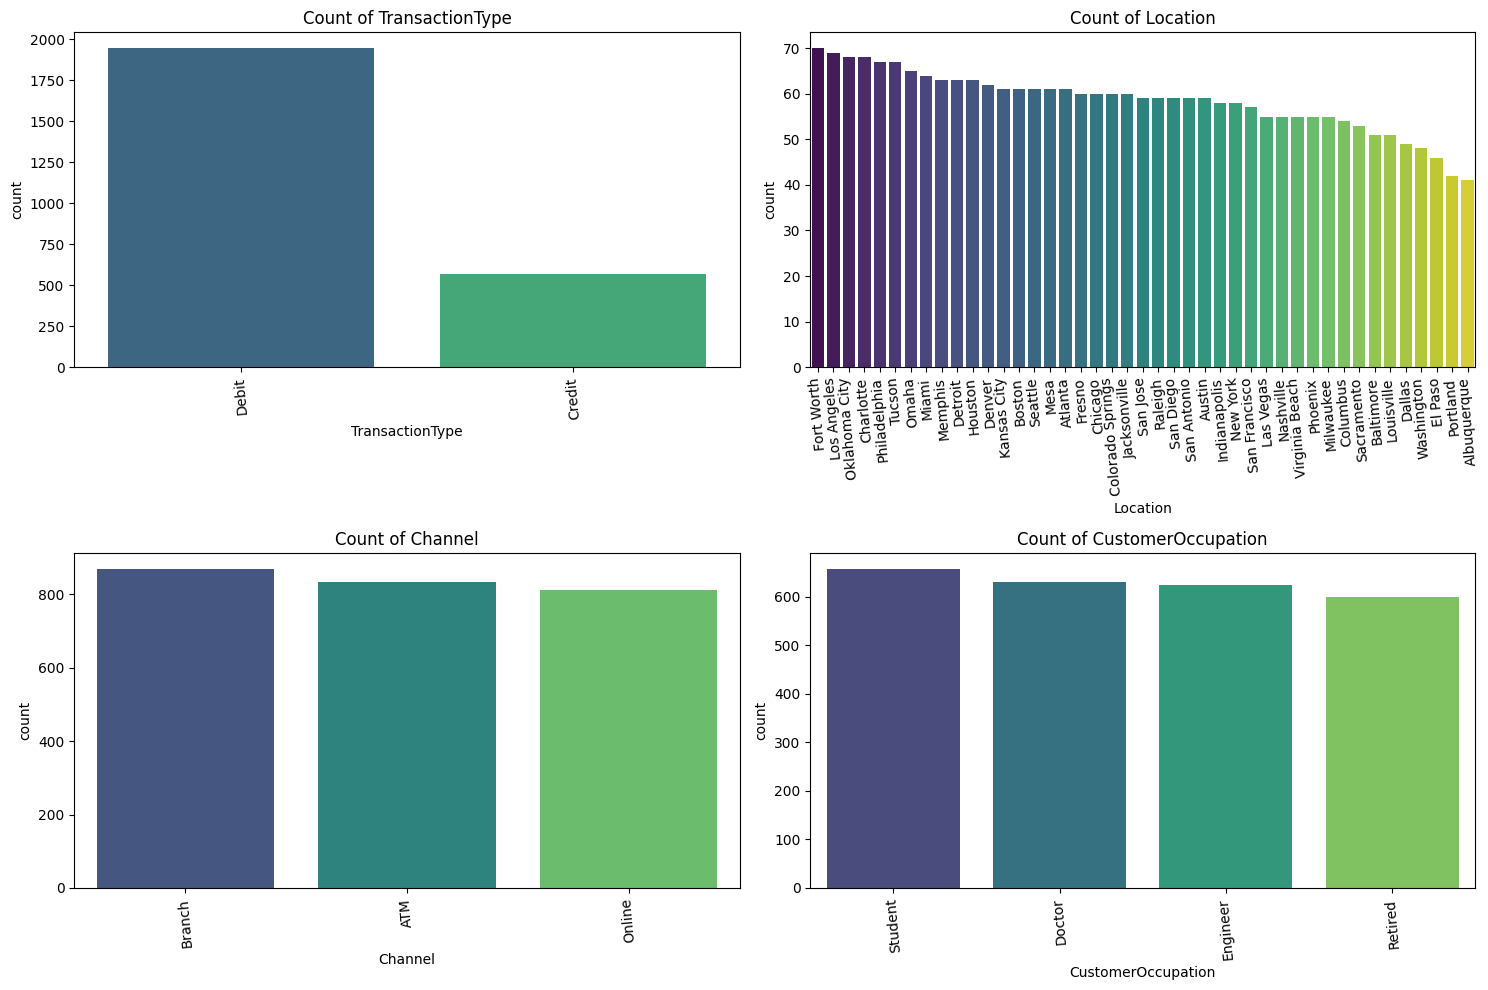

In [ ]:
# Count plots for categorical variables
categorical_columns = ["TransactionType", "Location", "Channel", "CustomerOccupation"]

plt.figure(figsize=(15, 10))
for i, col in enumerate(categorical_columns, 1):
    plt.subplot(2, 2, i)
    sns.countplot(x=bank[col], palette="viridis", order=bank[col].value_counts().index)
    plt.title(f"Count of {col}")
    plt.xticks(rotation=95)
plt.tight_layout()
plt.show()


In [ ]:
# General information about the data
bank.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2512 entries, 0 to 2511
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   TransactionID            2512 non-null   object 
 1   AccountID                2512 non-null   object 
 2   TransactionAmount        2512 non-null   float64
 3   TransactionDate          2512 non-null   object 
 4   TransactionType          2512 non-null   object 
 5   Location                 2512 non-null   object 
 6   DeviceID                 2512 non-null   object 
 7   IP Address               2512 non-null   object 
 8   MerchantID               2512 non-null   object 
 9   Channel                  2512 non-null   object 
 10  CustomerAge              2512 non-null   int64  
 11  CustomerOccupation       2512 non-null   object 
 12  TransactionDuration      2512 non-null   int64  
 13  LoginAttempts            2512 non-null   int64  
 14  AccountBalance          

In [ ]:
# Data Summary Statistics
bank.describe().T

,count,mean,std,min,25%,50%,75%,max
TransactionAmount,2512.0,297.593778,291.946243,0.26,81.885,211.14,414.5275,1919.11
CustomerAge,2512.0,44.673965,17.792198,18.00,27.000,45.00,59.0000,80.00
TransactionDuration,2512.0,119.643312,69.963757,10.00,63.000,112.50,161.0000,300.00
LoginAttempts,2512.0,1.124602,0.602662,1.00,1.000,1.00,1.0000,5.00
AccountBalance,2512.0,5114.302966,3900.942499,101.25,1504.370,4735.51,7678.8200,14977.99


## **Handiling Categrical columns**


In [ ]:
# Getting all categorical columns
categorical_columns = bank.select_dtypes(include=['object']).columns
print(categorical_columns)

Index(['TransactionID', 'AccountID', 'TransactionDate', 'TransactionType',
       'Location', 'DeviceID', 'IP Address', 'MerchantID', 'Channel',
       'CustomerOccupation', 'PreviousTransactionDate'],
      dtype='object')


In [ ]:
# The transactionID column
print('TransactionID unique values:', bank['TransactionID'].nunique())

'''
The transacction ID column has 2512 unique values meaning that all the inputs in the columns are unique
'''
# The AccountID column
print('BankID column unique values:', bank['AccountID'].nunique())

'''
The AccountID column has 495 unique values meaning that all the inputs in the columns are unique.
This Clearly  tells us that therea are 495 diffrent accounts.
'''

TransactionID unique values: 2512
BankID column unique values: 495


'\nThe AccountID column has 2512 unique values meaning that all the inputs in the columns are unique\n'

In [ ]:
# Getting top five occuring accountsID transaction
bank['AccountID'].value_counts().head()

,count
AccountID,
AC00460,12
AC00202,12
AC00362,12
AC00363,12
AC00480,11


In [ ]:
# Transaction Types unique values
print('Transaction Types unique values:', bank['TransactionType'].nunique())
# Transaction types categories name
print('Transaction Types categories name:', bank['TransactionType'].unique(),'\n')
# Number of observations per value
print('Number of observations per value:\n','\n', bank['TransactionType'].value_counts())

Transaction Types unique values: 2
Transaction Types categories name: ['Debit' 'Credit'] 

Number of observations per value:
 
 TransactionType
Debit     1944
Credit     568
Name: count, dtype: int64


([0, 1], [Text(0, 0, 'Debit'), Text(1, 0, 'Credit')])

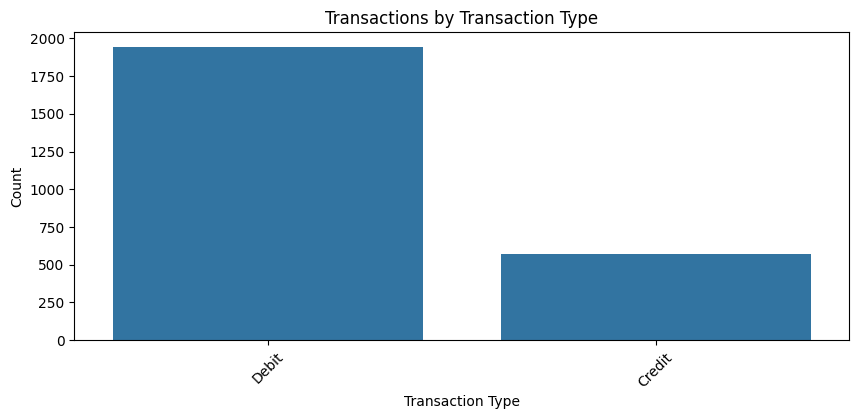

In [ ]:
# Visualize transactions by transaction type
plt.figure(figsize=(10, 4))
sns.countplot(data=bank, x='TransactionType')
plt.title('Transactions by Transaction Type')
plt.xlabel('Transaction Type')
plt.ylabel('Count')
plt.xticks(rotation=45)

Location unique values: 43
Location categories name: ['San Diego' 'Houston' 'Mesa' 'Raleigh' 'Atlanta' 'Oklahoma City'
 'Seattle' 'Indianapolis' 'Detroit' 'Nashville' 'Albuquerque' 'Memphis'
 'Louisville' 'Denver' 'Austin' 'Columbus' 'Los Angeles' 'Las Vegas'
 'Fort Worth' 'Miami' 'Milwaukee' 'Baltimore' 'New York' 'San Francisco'
 'San Jose' 'San Antonio' 'Philadelphia' 'Charlotte' 'Tucson' 'Chicago'
 'Sacramento' 'Kansas City' 'Omaha' 'Virginia Beach' 'Dallas' 'Boston'
 'Jacksonville' 'Phoenix' 'Washington' 'El Paso' 'Colorado Springs'
 'Fresno' 'Portland']


([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35,
  36,
  37,
  38,
  39,
  40,
  41,
  42],
 [Text(0, 0, 'Fort Worth'),
  Text(1, 0, 'Los Angeles'),
  Text(2, 0, 'Oklahoma City'),
  Text(3, 0, 'Charlotte'),
  Text(4, 0, 'Philadelphia'),
  Text(5, 0, 'Tucson'),
  Text(6, 0, 'Omaha'),
  Text(7, 0, 'Miami'),
  Text(8, 0, 'Memphis'),
  Text(9, 0, 'Detroit'),
  Text(10, 0, 'Houston'),
  Text(11, 0, 'Denver'),
  Text(12, 0, 'Kansas City'),
  Text(13, 0, 'Boston'),
  Text(14, 0, 'Seattle'),
  Text(15, 0, 'Mesa'),
  Text(16, 0, 'Atlanta'),
  Text(17, 0, 'Fresno'),
  Text(18, 0, 'Chicago'),
  Text(19, 0, 'Colorado Springs'),
  Text(20, 0, 'Jacksonville'),
  Text(21, 0, 'San Jose'),
  Text(22, 0, 'Raleigh'),
  Text(23, 0, 'San Diego'),
  Text(24, 0, 'San Antonio'),
  Text(25, 0, 'Austin'),
  Text(26, 0, 'Indianapolis'),
  Text(27, 0, 'New Yo

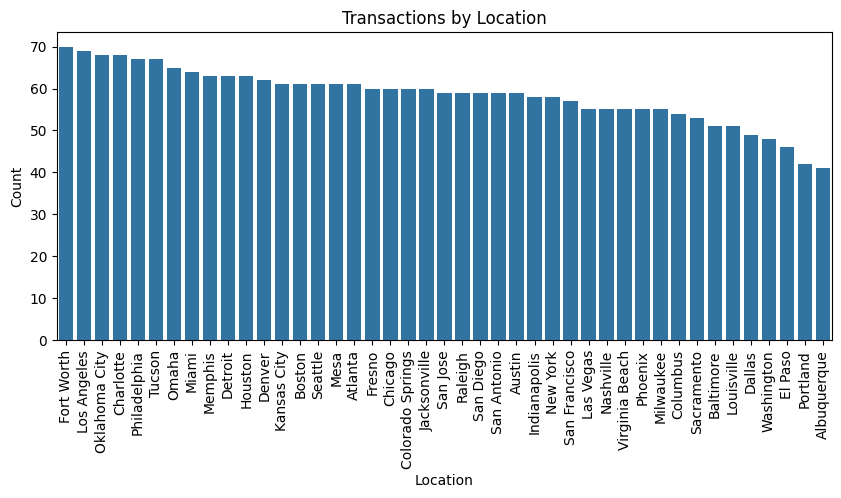

In [ ]:
# Loacation column
print('Location unique values:', bank['Location'].nunique())
# Location categories name
print('Location categories name:', bank['Location'].unique())
# Plot location by number of transactions and arrange in descendig order
plt.figure(figsize=(10, 4))
sns.countplot(data=bank, x='Location', order=bank['Location'].value_counts().index)
plt.title('Transactions by Location')
plt.xlabel('Location')
plt.ylabel('Count')
plt.xticks(rotation=90)


In [ ]:
# Manupulating DeviceID
print('DeviceID unique values:', bank['DeviceID'].nunique())


DeviceID unique values: 681


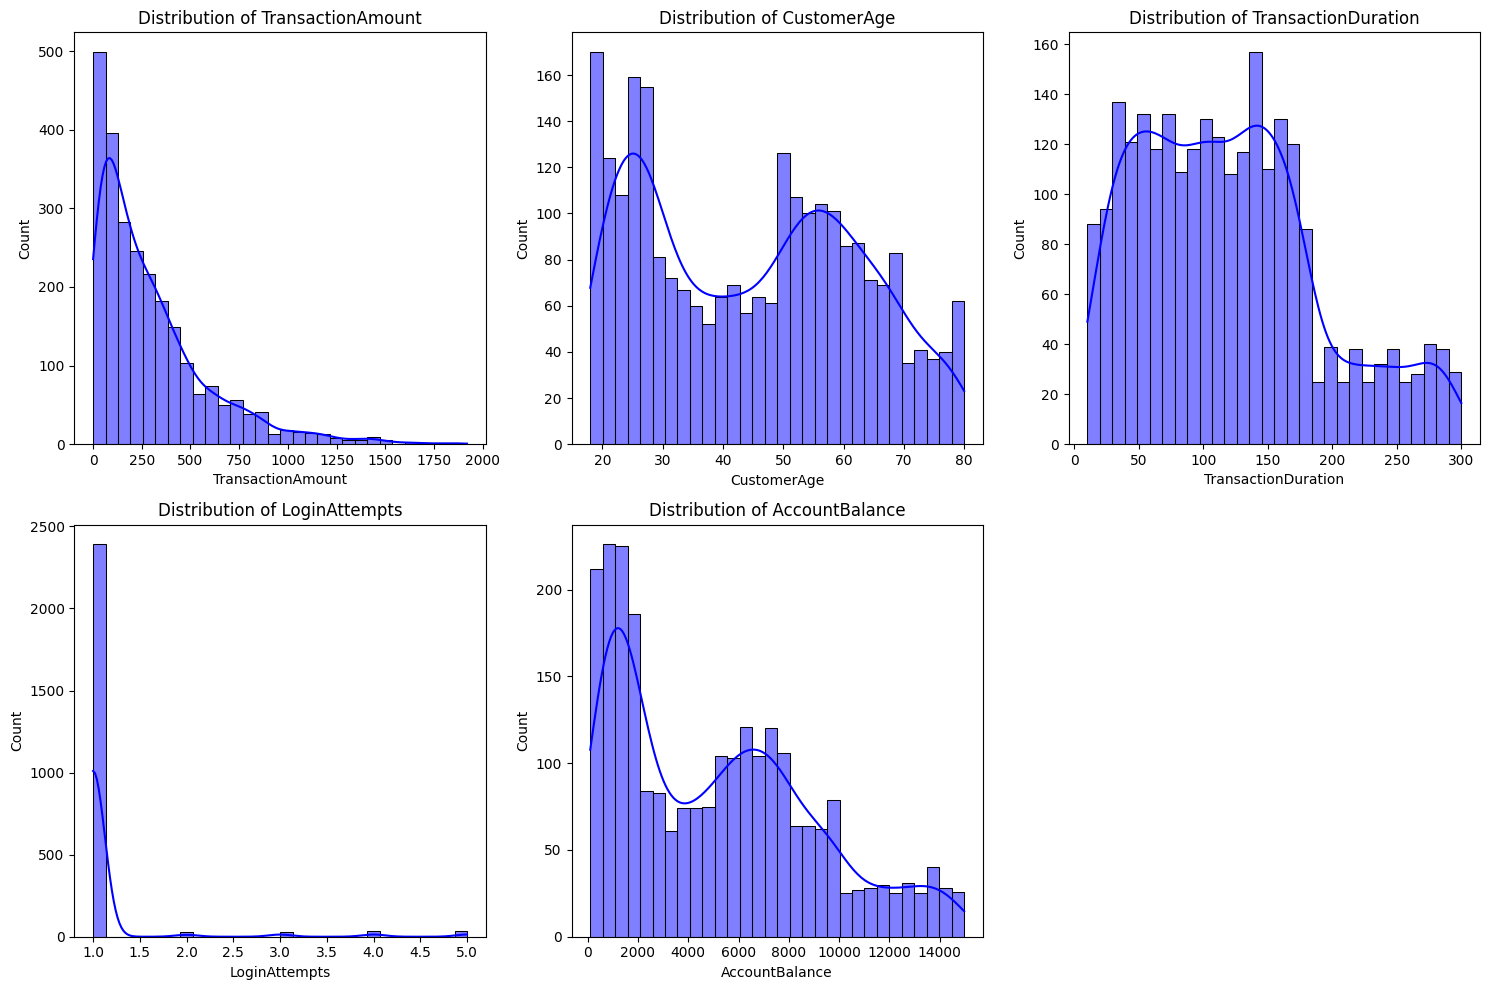

In [ ]:
# Plot distributions of numerical variables
numerical_columns = ["TransactionAmount", "CustomerAge", "TransactionDuration", "LoginAttempts", "AccountBalance"]

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_columns, 1):
    plt.subplot(2, 3, i)
    sns.histplot(bank[col], kde=True, bins=30, color="blue")
    plt.title(f"Distribution of {col}")
plt.tight_layout()
plt.show()


Channel unique values: 3
Channel categories name: ['ATM' 'Online' 'Branch'] 



Text(0, 0.5, '')

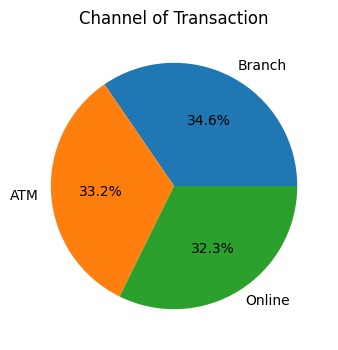

In [ ]:
# Channel Column
print('Channel unique values:', bank['Channel'].nunique())
# Channel categories name
print('Channel categories name:', bank['Channel'].unique(),'\n')

# pie chart for channel
plt.figure(figsize=(10, 4))
bank['Channel'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Channel of Transaction')
plt.ylabel('')

In [ ]:
# Occupation Category
print('Occupation unique values:', bank['CustomerOccupation'].nunique())
# Occupation categories name
print('Occupation categories name:', bank['CustomerOccupation'].unique(),'\n')
# No. of observations per catgory
print('Number of observations per value:\n','\n', bank['CustomerOccupation'].value_counts())


Occupation unique values: 4
Occupation categories name: ['Doctor' 'Student' 'Retired' 'Engineer'] 

Number of observations per value:
 
 CustomerOccupation
Student     657
Doctor      631
Engineer    625
Retired     599
Name: count, dtype: int64


Text(0, 0.5, 'Count')

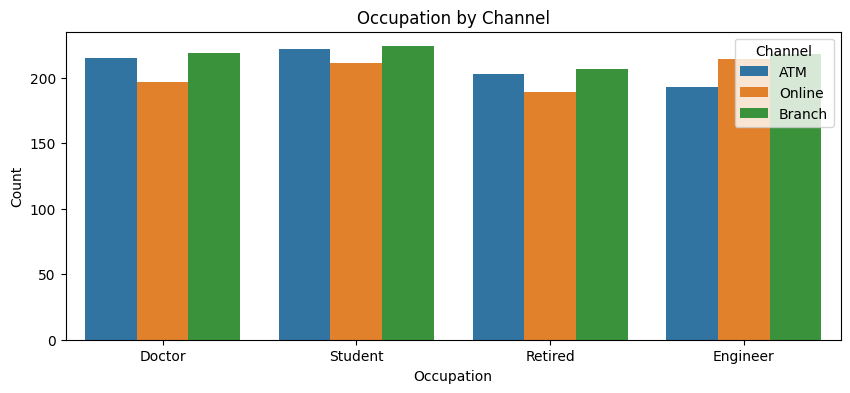

In [ ]:
# Occupation by channel
plt.figure(figsize=(10, 4))
sns.countplot(data=bank, x='CustomerOccupation', hue='Channel')
plt.title('Occupation by Channel')
plt.xlabel('Occupation')
plt.ylabel('Count')

Text(0, 0.5, 'Count')

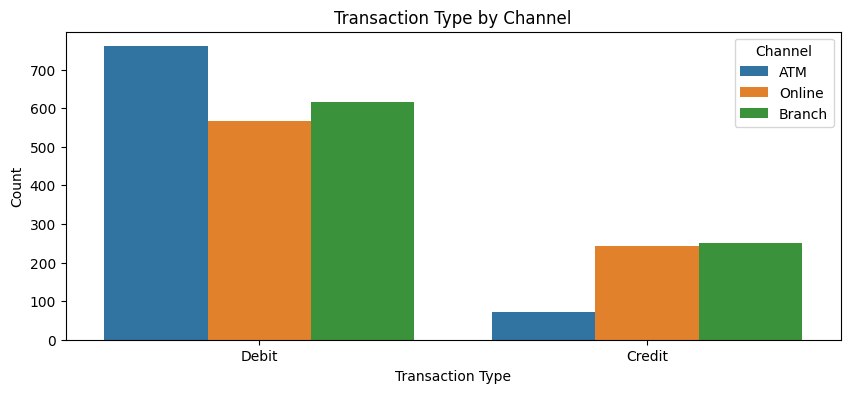

In [ ]:
# Transaction type by channel
plt.figure(figsize=(10, 4))
sns.countplot(data=bank, x='TransactionType', hue='Channel')
plt.title('Transaction Type by Channel')
plt.xlabel('Transaction Type')
plt.ylabel('Count')
#

In [ ]:
# Converting Dates to Date
bank['TransactionDate'] = pd.to_datetime(bank['TransactionDate'], format='%d/%m/%Y %H:%M')
# Converting Dates to Date
bank['PreviousTransactionDate'] = pd.to_datetime(bank['PreviousTransactionDate'], format='%d/%m/%Y %H:%M')

## **Handling Numeric Columns**


In [ ]:
# Getting a list of all numerical columns
numerical_columns = bank.select_dtypes(include=['int64', 'float64']).columns
print(numerical_columns)

Index(['TransactionAmount', 'CustomerAge', 'TransactionDuration',
       'LoginAttempts', 'AccountBalance'],
      dtype='object')


In [ ]:
# Summary Statistics of the TransactionAmount Column
print(bank['TransactionAmount'].describe())

count    2512.000000
mean      297.593778
std       291.946243
min         0.260000
25%        81.885000
50%       211.140000
75%       414.527500
max      1919.110000
Name: TransactionAmount, dtype: float64


Text(0.5, 1.0, 'Customer Age Distribution')

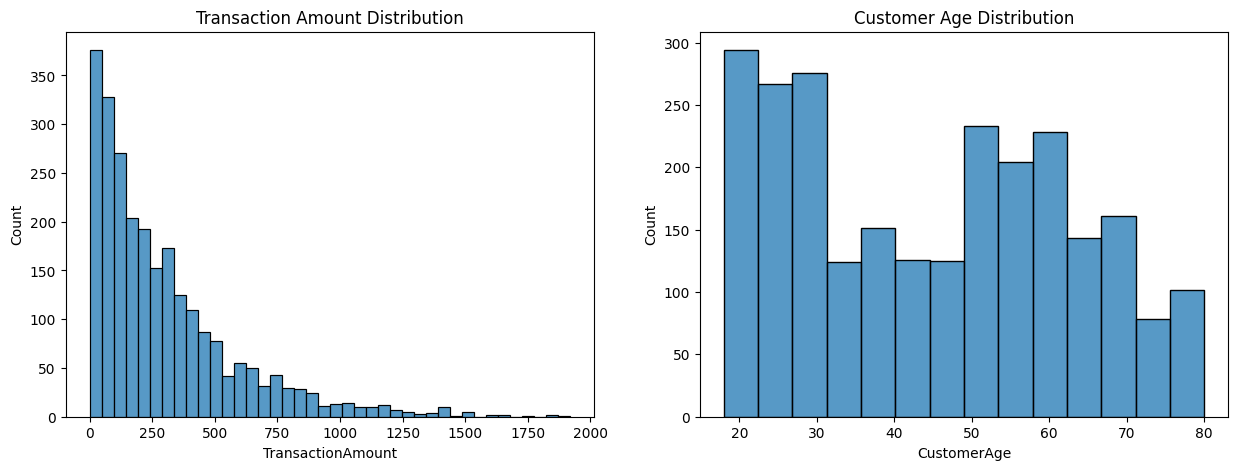

In [ ]:
# The distribution of the transaction amount and customer age subplots
fig, axs = plt.subplots(1, 2, figsize=(15, 5))
sns.histplot(bank['TransactionAmount'], ax=axs[0])
axs[0].set_title('Transaction Amount Distribution')
sns.histplot(bank['CustomerAge'], ax=axs[1])
axs[1].set_title('Customer Age Distribution')


Text(0.5, 1.0, 'Account Balance Distribution')

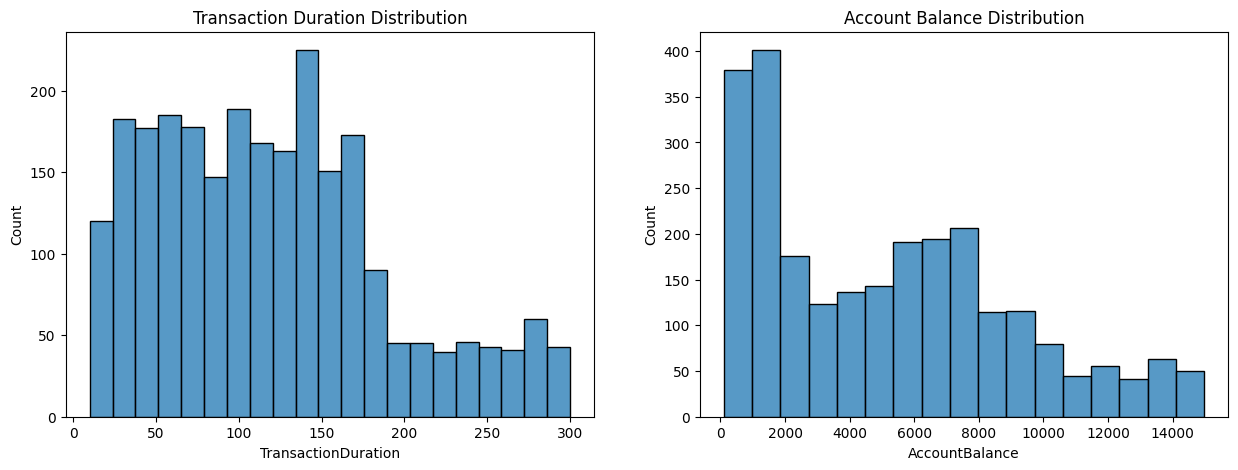

In [ ]:
# The distribution of transaction duration and account balane
fig, axs = plt.subplots(1, 2, figsize=(15, 5))
sns.histplot(bank['TransactionDuration'], ax=axs[0])
axs[0].set_title('Transaction Duration Distribution')
sns.histplot(bank['AccountBalance'], ax=axs[1])
axs[1].set_title('Account Balance Distribution')

Text(0, 0.5, 'Account Balance')

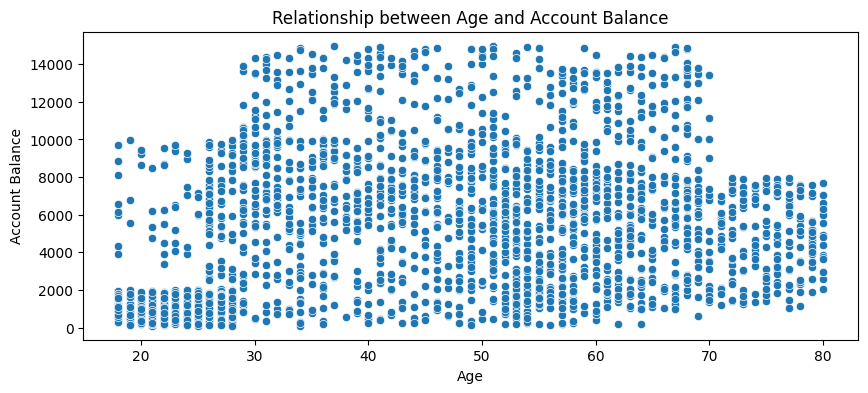

In [ ]:
# Relationship between age and account balance
plt.figure(figsize=(10, 4))
sns.scatterplot(data=bank, x='CustomerAge', y='AccountBalance')
plt.title('Relationship between Age and Account Balance')
plt.xlabel('Age')
plt.ylabel('Account Balance')
#

# Feature engineering


In [ ]:
# Label encoding categorical variables
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
bank['Location'] = le.fit_transform(bank['Location'])
bank['CustomerOccupation'] = le.fit_transform(bank['CustomerOccupation'])
bank['Channel'] = le.fit_transform(bank['Channel'])
bank['TransactionType'] = le.fit_transform(bank['TransactionType'])

In [ ]:
# Tail of the Encoded categorical variables
print(bank['Location'].tail())
print(bank['CustomerOccupation'].tail())
print(bank['Channel'].tail())
print(bank['TransactionType'].tail())

2507     7
2508    40
2509    36
2510    10
2511    17
Name: Location, dtype: int64
2507    0
2508    0
2509    2
2510    3
2511    3
Name: CustomerOccupation, dtype: int64
2507    1
2508    1
2509    1
2510    2
2511    2
Name: Channel, dtype: int64
2507    0
2508    1
2509    1
2510    1
2511    0
Name: TransactionType, dtype: int64


In [ ]:
# Feature Scaling numerical variables
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
bank[['TransactionAmount', 'TransactionDuration', 'CustomerAge', 'AccountBalance']] = scaler.fit_transform(bank[['TransactionAmount', 'TransactionDuration', 'CustomerAge', 'AccountBalance']])

In [ ]:
# Tail of the transformed bank data
bank.tail()


,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate
2507,TX002508,AC00297,1.913802,2023-04-26 17:09:00,0,7,D000625,21.157.41.17,M072,1,-0.656259,0,-0.152156,1,1.942606,2024-11-04 08:11:00
2508,TX002509,AC00322,-0.157779,2023-03-22 17:36:00,1,40,D000410,49.174.157.140,M029,1,0.186975,0,0.819969,1,-1.245986,2024-11-04 08:11:00
2509,TX002510,AC00095,-0.921462,2023-08-21 17:08:00,1,36,D000095,58.1.27.124,M087,1,0.636700,2,0.376794,1,-0.443928,2024-11-04 08:08:00
2510,TX002511,AC00118,-0.382420,2023-02-24 16:24:00,1,10,D000634,21.190.11.223,M041,2,-1.218415,3,-1.438793,1,-0.855705,2024-11-04 08:12:00
2511,TX002512,AC00009,-0.186763,2023-02-14 16:21:00,0,17,D000215,59.127.135.25,M041,2,-1.162199,3,-0.380892,1,-1.277652,2024-11-04 08:07:00


In [ ]:
# Droping some columns that may not be really necesary
bank = bank.drop(['TransactionID','AccountID','DeviceID',
                  'IP Address', 'MerchantID', 'PreviousTransactionDate'], axis=1)

In [ ]:
bank.head()

,TransactionAmount,TransactionDate,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance
0,-0.971275,2023-04-11 16:29:00,1,36,0,1.423718,0,-0.552443,1,-0.000537
1,0.269440,2023-06-27 16:44:00,1,15,0,1.311287,0,0.305314,1,2.216472
2,-0.586882,2023-07-10 18:16:00,1,23,2,-1.443277,3,-0.909842,1,-1.023534
3,-0.387456,2023-05-05 16:32:00,1,33,2,-1.049768,3,-1.353017,1,0.885797
4,-0.973468,2023-10-16 17:51:00,0,1,2,-1.049768,3,1.120184,1,0.593589


In [ ]:
# Apply Dimensionality reduction
from sklearn.decomposition import PCA
pca = PCA(n_components=2)

# Convert 'TransactionDate' to numerical representation
# Assuming 'TransactionDate' is the datetime column causing the issue
bank['TransactionDate_Numeric'] = bank['TransactionDate'].astype(int) / 10**9

# Exclude original 'TransactionDate' and any other non-numeric columns
# The 'TransactionDate' is dropped here from the original DataFrame
numerical_features = bank.drop(columns=['TransactionDate']).select_dtypes(include=['number'])

# Fit and transform PCA on numerical features only
bank_pca = pca.fit_transform(numerical_features)

In [ ]:
# Apply DBscan clustering
from sklearn.cluster import DBSCAN
dbscan = DBSCAN(eps=0.5, min_samples=5)
cluster_labels = dbscan.fit_predict(bank_pca)

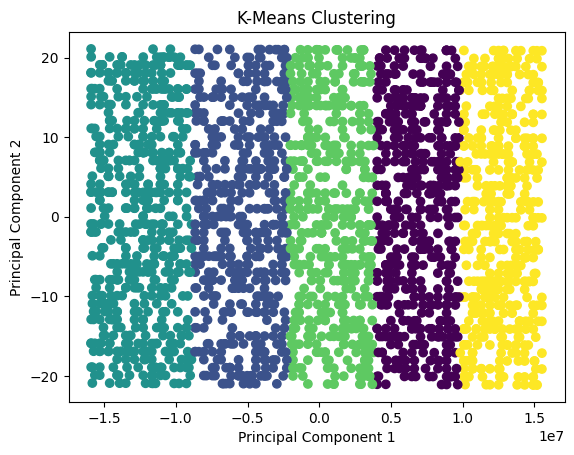

In [ ]:
# From the scaled data, I need to form clusters
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=5, random_state=42)
cluster_labels = kmeans.fit_predict(bank_pca)
# plot the clusters
plt.scatter(bank_pca[:, 0], bank_pca[:, 1], c=cluster_labels)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('K-Means Clustering')
plt.show()

In [ ]:
# From the bank data, lets apply DBscan
from sklearn.cluster import DBSCAN
dbscan = DBSCAN(eps=0.5, min_samples=5)
cluster_labels = dbscan.fit_predict(bank_)


NameError: name 'bank' is not defined

In [ ]:
# From the bank data, lets apply DBscan
from sklearn.cluster import DBSCAN
dbscan = DBSCAN(eps=0.5, min_samples=5)

# Exclude 'TransactionDate' and any other non-numeric columns from clustering
# You should include all relevant numerical features for clustering
# For example, if 'TransactionAmount', 'CustomerAge', and 'AccountBalance' are important:
features_for_clustering = bank[['TransactionAmount', 'CustomerAge', 'AccountBalance']]

cluster_labels = dbscan.fit_predict(features_for_clustering)

NameError: name 'bank' is not defined